# Basic Data Visualization with MTurk Flood Risk Data (Python + Plotly + Seaborn)

Goal: To explore, summarize, and visualize the FLOODPERCEP dataset using Pandas, Matplotlib/Seaborn, and Plotly.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



## 1. Load Data

In [3]:
# Read the dataset
data = pd.read_csv("../data/mturk_data.csv", dtype=str)

# Inspect basic info
print(data.shape)
print(data.columns.tolist())
data.head()

(1592, 37)
['participant_id', 'participant_longitude', 'participant_latitude', 'participant_zip_code', 'participant_city', 'participant_state', 'age', 'gender', 'hispanic_or_latino', 'race', 'race_self_identify_text', 'education_level', 'languages_home', 'languages_home_other', 'last_flood_experience', 'flood_preparation_actions', 'flood_response_actions', 'flood_map_experience', 'flood_map_experience_other', 'selected_folder', 'selected_image', 'image_longitude', 'image_latitude', 'image_zip_code', 'image_city', 'image_state', 'flood_risk_severity', 'flood_frequency', 'flood_risk_understanding', 'confidence_in_map', 'likely_to_buy_property', 'likely_to_rent_property', 'likely_to_buy_insurance', 'likely_to_take_preventive_actions', 'use_flood_maps_frequency', 'ease_of_interpretation', 'additional_comments']


,participant_id,participant_longitude,participant_latitude,participant_zip_code,participant_city,participant_state,age,gender,hispanic_or_latino,race,...,flood_frequency,flood_risk_understanding,confidence_in_map,likely_to_buy_property,likely_to_rent_property,likely_to_buy_insurance,likely_to_take_preventive_actions,use_flood_maps_frequency,ease_of_interpretation,additional_comments
0,001,-82.2911,27.9032,33511,Brandon,Florida,35 to 44,Male,No,White,...,5,Very well,Extremely confident,Somewhat likely,Somewhat likely,Somewhat likely,Somewhat likely,Sometimes,Somewhat easy,NaN
1,001,-82.2911,27.9032,33511,Brandon,Florida,35 to 44,Male,No,White,...,3,Moderately well,Somewhat confident,Somewhat likely,Neither likely nor unlikely,Somewhat likely,Neither likely nor unlikely,Sometimes,Neither easy nor difficult,NaN
2,002,-97.822,37.751,20790,Capitol Heights,Maryland,25 to 34,Male,Yes,White,...,moderate to high,Extremely well,Very confident,Somewhat likely,Very likely,Somewhat likely,Somewhat likely,Sometimes,Somewhat difficult,NaN
3,002,-97.822,37.751,20790,Capitol Heights,Maryland,25 to 34,Male,Yes,White,...,moderate to high,Very well,Slightly confident,Very likely,Somewhat likely,Somewhat likely,Very likely,Sometimes,Somewhat difficult,NaN
4,003,-97.822,37.751,20120,Centreville,Virginia,25 to 34,Male,Yes,Asian,...,3 year,Very well,Very confident,Somewhat likely,Very likely,Somewhat likely,Very likely,Often,Somewhat easy,flood areas


In [4]:

print(data.isnull().sum())

# Columns to check
cols = ["flood_frequency", "participant_state", "participant_longitude"]

# Print rows where ANY of these columns is null
null_rows = data[data[cols].isnull().any(axis=1)]
null_rows

participant_id                          0
participant_longitude                   2
participant_latitude                    2
participant_zip_code                    0
participant_city                        0
participant_state                       2
age                                     0
gender                                  0
hispanic_or_latino                      0
race                                    0
race_self_identify_text              1584
education_level                         0
languages_home                          0
languages_home_other                 1588
last_flood_experience                   0
flood_preparation_actions               0
flood_response_actions                  0
flood_map_experience                    0
flood_map_experience_other           1592
selected_folder                         0
selected_image                          0
image_longitude                         0
image_latitude                          0
image_zip_code                    

,participant_id,participant_longitude,participant_latitude,participant_zip_code,participant_city,participant_state,age,gender,hispanic_or_latino,race,...,flood_frequency,flood_risk_understanding,confidence_in_map,likely_to_buy_property,likely_to_rent_property,likely_to_buy_insurance,likely_to_take_preventive_actions,use_flood_maps_frequency,ease_of_interpretation,additional_comments
898,450,-122.2972,47.63,99502,Anchorage,Alaska,18 to 24,Male,Yes,White,...,NaN,Extremely well,Not at all confident,Very unlikely,Very unlikely,Very unlikely,Very unlikely,Never,Extremely easy,NaN
899,450,-122.2972,47.63,99502,Anchorage,Alaska,18 to 24,Male,Yes,White,...,NaN,Extremely well,Not at all confident,Very unlikely,Very unlikely,Very unlikely,Very unlikely,Never,Extremely easy,NaN
1040,521,NaN,NaN,95621,Citrus Heights,California,65 or over,Male,No,White,...,every 2 years,Moderately well,Slightly confident,Very unlikely,Very unlikely,Very likely,Somewhat likely,Sometimes,Neither easy nor difficult,NaN
1041,521,NaN,NaN,95621,Citrus Heights,California,65 or over,Male,No,White,...,once every 2 years,Moderately well,Somewhat confident,Very unlikely,Very unlikely,Very likely,Somewhat likely,Never,Neither easy nor difficult,NaN
1342,672,-97.822,37.751,20032,Washington,NaN,25 to 34,Male,No,White,...,5 years,Moderately well,Somewhat confident,Neither likely nor unlikely,Somewhat likely,Somewhat likely,Somewhat likely,Sometimes,Somewhat difficult,"If the map includes elevation data, that can b..."
1343,672,-97.822,37.751,20032,Washington,NaN,25 to 34,Male,No,White,...,5 years,Moderately well,Somewhat confident,Somewhat likely,Neither likely nor unlikely,Neither likely nor unlikely,Neither likely nor unlikely,Often,Somewhat difficult,"In some cases, maps might not fully account fo..."


## 2.Summary Staistics

In [5]:
data.describe(include='all').T.head(10)

,count,unique,top,freq
participant_id,1592,796,001,2
participant_longitude,1590,86,-97.822,1094
participant_latitude,1590,85,37.751,1094
participant_zip_code,1592,411,20120,184
participant_city,1592,320,Centreville,184
participant_state,1590,44,Texas,212
age,1592,6,25 to 34,924
gender,1592,2,Male,1124
hispanic_or_latino,1592,2,No,864
race,1592,16,White,1198


##  3.Demographic Visualizations (Seaborn/Matplotlib)

### 3.1. Distribution of Visualization Types shown to Participants

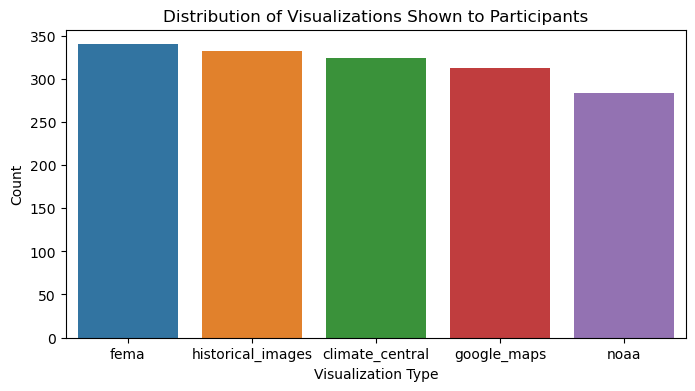

In [6]:


plt.figure(figsize=(8, 4))
sns.countplot(x='selected_folder', data=data, order=data['selected_folder'].value_counts().index)
plt.title("Distribution of Visualizations Shown to Participants")
plt.xlabel("Visualization Type")
plt.ylabel("Count")
plt.show()

### 3.2 Age Distribution

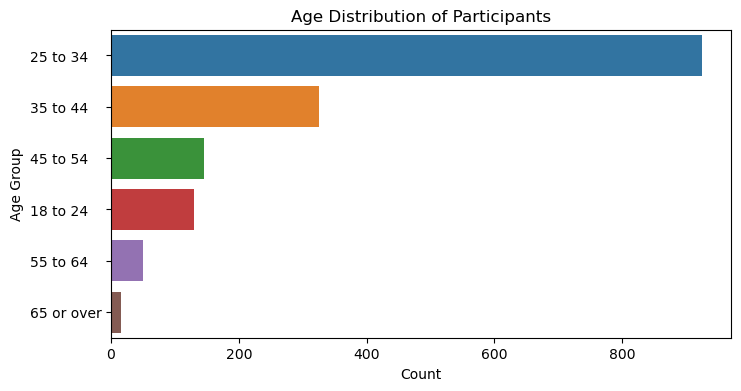

In [7]:
plt.figure(figsize=(8, 4))
sns.countplot(y='age', data=data, order=data['age'].value_counts().index)
plt.title("Age Distribution of Participants")
plt.ylabel("Age Group")
plt.xlabel("Count")
plt.show()

### 3.3 Gender Distribution

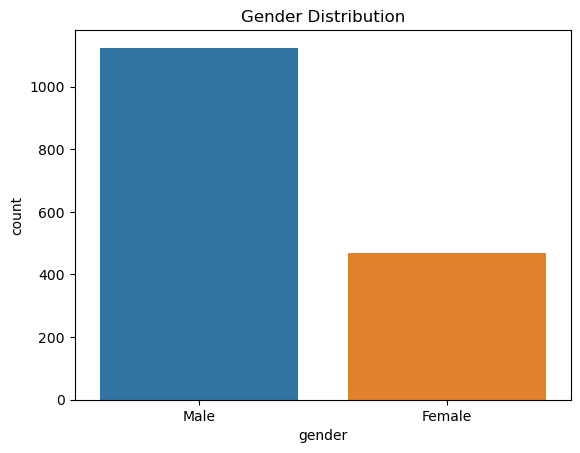

In [8]:
sns.countplot(x='gender', data=data)
plt.title("Gender Distribution")
plt.show()

## 4. Geographical Visualizations

In [9]:
data.columns

Index(['participant_id', 'participant_longitude', 'participant_latitude',
       'participant_zip_code', 'participant_city', 'participant_state', 'age',
       'gender', 'hispanic_or_latino', 'race', 'race_self_identify_text',
       'education_level', 'languages_home', 'languages_home_other',
       'last_flood_experience', 'flood_preparation_actions',
       'flood_response_actions', 'flood_map_experience',
       'flood_map_experience_other', 'selected_folder', 'selected_image',
       'image_longitude', 'image_latitude', 'image_zip_code', 'image_city',
       'image_state', 'flood_risk_severity', 'flood_frequency',
       'flood_risk_understanding', 'confidence_in_map',
       'likely_to_buy_property', 'likely_to_rent_property',
       'likely_to_buy_insurance', 'likely_to_take_preventive_actions',
       'use_flood_maps_frequency', 'ease_of_interpretation',
       'additional_comments'],
      dtype='object')

## Distribution of Flood Visualizations

In [10]:
fig = px.scatter_geo(
    data,
    lat='image_latitude',
    lon='image_longitude',
    color='selected_folder',
    hover_name='image_city',
    hover_data=['image_state', 'image_zip_code'],
    title="Geographical distribution of Images by Visualization Type"
)
fig.show()

## Distribution of Participants 

In [11]:
fig = px.scatter_geo(
    data,
    lat='participant_latitude',
    lon='participant_longitude',
    color='selected_folder',
    hover_name='participant_city',
    hover_data=['participant_state', 'participant_zip_code'],
    title="Geographical distribution of Participants by Visualization Type"
)
fig.show()

## 5. Likert Scale Visualizations

### 5.1 Heatmap of Average Scores per Folder

In [12]:
# Define the Likert-scale perception columns
LIKERT = [
    'flood_risk_severity',
    'flood_risk_understanding',
    'confidence_in_map',
    'likely_to_buy_property',
    'likely_to_rent_property',
    'likely_to_buy_insurance',
    'likely_to_take_preventive_actions',
    'use_flood_maps_frequency',
    'ease_of_interpretation'
]

# Define the numrical mappings for Likert-scale responses
mappings = {'flood_risk_severity': {'Very High': 1,  'High': 2,  'Moderate': 3,  'Low': 4,  'Very Low': 5},
 'flood_risk_understanding': {'Extremely well': 1,  'Very well': 2,  'Moderately well': 3,  'Slightly well': 4,  'Not well at all': 5},
 'confidence_in_map': {'Extremely confident': 1,  'Very confident': 2,'Somewhat confident': 3,  'Slightly confident': 4,  'Not at all confident': 5},
 'likely_to_buy_property': {'Very likely': 1,  'Somewhat likely': 2,  'Neither likely nor unlikely': 3,  'Somewhat unlikely': 4,  'Very unlikely': 5},
 'likely_to_rent_property': {'Very likely': 1,  'Somewhat likely': 2,  'Neither likely nor unlikely': 3,  'Somewhat unlikely': 4,  'Very unlikely': 5},
 'likely_to_buy_insurance': {'Very likely': 1,  'Somewhat likely': 2,  'Neither likely nor unlikely': 3,  'Somewhat unlikely': 4,  'Very unlikely': 5},
 'likely_to_take_preventive_actions': {'Very likely': 1,  'Somewhat likely': 2,  'Neither likely nor unlikely': 3,  'Somewhat unlikely': 4,  'Very unlikely': 5},
 'use_flood_maps_frequency': {'Always': 1,  'Often': 2,  'Sometimes': 3,  'Rarely': 4,  'Never': 5},
 'ease_of_interpretation': {'Extremely easy': 1,  'Somewhat easy': 2,  'Neither easy nor difficult': 3,  'Somewhat difficult': 4,  'Extremely difficult': 5}}


for col in LIKERT:
    # Map text → numeric
    data[col] = data[col].map(mappings[col])
    
    # Coerce remaining values (if numeric strings) to numeric
    data[col] = pd.to_numeric(data[col], errors='coerce')

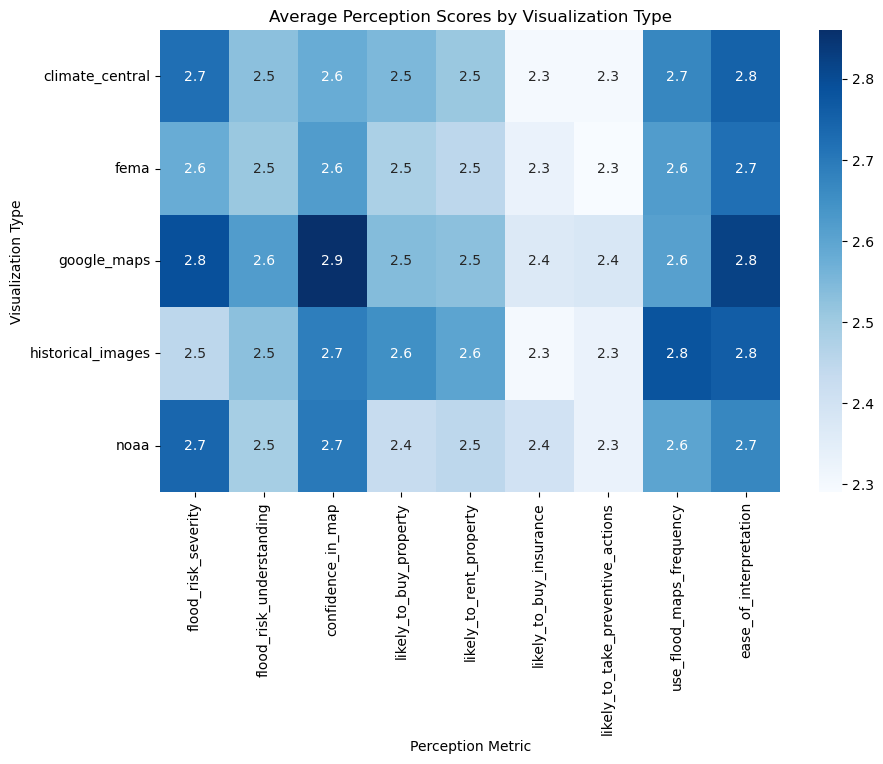

In [13]:
 # --- Group and plot ---
folder_means = data.groupby('selected_folder')[LIKERT].mean().round(2)

plt.figure(figsize=(10, 6))
sns.heatmap(folder_means, annot=True, cmap='Blues')
plt.title("Average Perception Scores by Visualization Type")
plt.ylabel("Visualization Type")
plt.xlabel("Perception Metric")
plt.show()

### 5.2 Distribution


Choose the Likert scale response you want to visualize. 


LIKERT = [
    'flood_risk_severity',
    'flood_risk_understanding',
    'confidence_in_map',
    'likely_to_buy_property',
    'likely_to_rent_property',
    'likely_to_buy_insurance',
    'likely_to_take_preventive_actions',
    'use_flood_maps_frequency',
    'ease_of_interpretation'
]

In [15]:
fig = px.box(
    data,
    x='selected_folder',
    y='confidence_in_map',
    color='selected_folder',
    hover_data=['age', 'education_level']
)
fig.update_layout(title="Interactive Boxplot: Confidence in Map by different Visualizations")
fig.show()